# Gadget4 vs StePS-PDS — head-to-head, and grid-load vs glass-load

A flat **Gadget4** run vs the curved **Poincaré-dodecahedral (S³/I\*)** StePS runs, from the
same realization and the same flat FLRW background, plus an A/B test of the PDS **particle
load**. All three runs are **256³, seed 137, 1200 Mpc, LCDM, z_start=31** — a matched set.

- **Gadget256 (flat)** — `gadget256_flat`, the flat T³ gold standard (Gadget4, PMGRID=256,
  same seed-137 flat realization as the PDS runs).
- **PDS grid-IC** — `test256disc`: discrete S³/I\* spectrum (n=12,20), rectangular
  stereographic **grid** load clipped to the dodecahedral domain.
- **PDS glass-IC** — `test256glass`: identical to the above **except** the unperturbed load
  is a reverse-gravity **glass** (relaxed from a Poisson load in an EdS background). This is
  the only difference, so it isolates what the load does.

Contents: **(1)** matched density slices at z=0, **(2)** density evolution, **(3)** power-
spectrum evolution, **(4)** P(k) ratios & growth, **(5)** grid-vs-glass high-k lattice imprint.

> **Frames.** For the comparison the PDS is kept in **stereographic** coordinates (the frame
> in which it shares Gadget's flat realization) with Gadget shifted by L/2 onto the same
> origin, so all panels show the *same* structures at matched resolution; the
> **geodesic-normal** map (≈ physical comoving, Ω≈2 stretch) is used only for the §2
> single-run physical evolution. The P(k) is measured in a **cube that fits entirely inside
> the dodecahedral domain** (`HALF=300` Mpc, corner 520 Mpc < the 491 Mpc inradius reach), so
> both runs sample only real, fully-populated volume — the dodecahedral boundary never enters
> the FFT window, and the large low-k "pedestal" that earlier (`HALF=400`) versions had to
> subtract is simply **absent** (it was a survey-window/mask artifact of the cube corners
> sticking out into vacuum; see caveats). Background is flat in all runs (Ω_m+Ω_Λ=1).

In [1]:
import numpy as np, h5py, os
import matplotlib.pyplot as plt
# Keep the committed notebook small: the density-slice panels are 300x300 arrays that
# matplotlib would otherwise render ~2400 px wide (74% of the file was embedded PNG, and
# git stores every re-execution in full). 72 dpi is still well above the data resolution.
plt.rcParams['figure.dpi'] = 72
from scipy.ndimage import gaussian_filter
from scipy.integrate import quad

# cosmology (shared, flat)
OM, OL, HUB = 0.3106, 0.6894, 0.67702
R_CURV  = 3100.0           # PDS curvature radius [Mpc]
A_START = 1.0/32.0         # z = 31

# P(k) analysis cube half-width [Mpc]. It MUST fit inside the dodecahedral fundamental
# domain (inradius ~491 Mpc at the faces, vertices ~608 Mpc). half=300 -> the cube corner
# sits at 300*sqrt(3) = 520 Mpc, verified 100% inside for the PDS runs (and trivially for
# the periodic Gadget box). Then BOTH runs sample only real, fully-populated volume, the
# dodecahedral boundary never enters the FFT window, and the large low-k "pedestal" (a pure
# survey-window/mask artifact) never arises -- so NO first-snapshot subtraction is needed.
# The old half=400 cube poked ~7% of its volume (the corners) out into vacuum, and it was
# that hard-edged empty shape, convolved into the FFT, that produced the ~4x low-k excess.
HALF = 300.0

# runs. All three are 256^3, seed 137, LCDM, 1200 Mpc, z_start=31 -- a matched-resolution
# set. Gadget256 is the flat T^3 reference (PMGRID=256). The two PDS runs add the discrete
# S^3/I* spectrum (n=12,20) and differ ONLY in the unperturbed particle load: a rectangular
# stereographic GRID (test256disc) vs a reverse-gravity GLASS (test256glass).
# Now a full 2x2: {Gadget flat T^3, StePS PDS} x {grid load, glass load}. The two Gadget
# runs are identical in every respect (same box, seed 137, softening, output times, binary
# and Config.sh) EXCEPT the unperturbed particle load, so 'load effect' and 'topology
# effect' can finally be separated instead of confounded.
RUNS = {
    'Gadget grid-IC':    dict(dir='/scratch/csabai/gadget256_flat',  kind='gadget', w=3, load='grid'),
    'Gadget glass-IC':   dict(dir='/scratch/csabai/gadget256_glass', kind='gadget', w=3, load='glass'),
    'PDS grid-IC':       dict(dir='/scratch/csabai/test256disc',     kind='pds',    w=4, load='grid'),
    'PDS glass-IC':      dict(dir='/scratch/csabai/test256glass',    kind='pds',    w=4, load='glass'),
}
ZLIST  = [30,15,10,5,3,2,1,0.7,0.5,0.2,0]   # all output lists are identical
IDX_OF = {z:i for i,z in enumerate(ZLIST)}

def Dgrow(a):
    I,_ = quad(lambda ap: 1.0/(ap*np.sqrt(OM/ap**3+OL))**3, 1e-8, a)
    return 2.5*OM*np.sqrt(OM/a**3+OL)*I
print('linear growth D(0)/D(31) =', round(Dgrow(1.0)/Dgrow(A_START), 2))

linear growth D(0)/D(31) = 25.13


In [2]:
def load_phys(run, idx):
    # load snapshot -> (positions in physical comoving Mpc, redshift)
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx))
    with h5py.File(f, 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
        z = float(h['Header'].attrs['Redshift'])
    if run['kind'] == 'gadget':
        x = x / HUB                                   # Mpc/h -> Mpc
    else:                                             # PDS: stereographic -> geodesic-normal
        r = np.sqrt((x**2).sum(1)); r = np.where(r < 1e-9, 1e-9, r)
        chi = 2.0*np.arctan2(r, R_CURV)               # geodesic angle from centre
        x = (R_CURV*chi/r)[:, None]*x                 # physical comoving distance along geodesic
    return x, z

# Matched-frame loader for head-to-head comparison with Gadget. The PDS shares Gadget's
# flat realization in STEREOGRAPHIC coords (the geodesic map stretches structures by Omega~2
# and pulls them out of register). The frame relation, verified by FFT phase correlation of
# the z=0 density fields (peak exactly at [600,600,600] Mpc):
#     x_gadget_box = x_pds_stereo + L/2     =>     x_matched = x_box - L/2.
# CAUTION: np.mod(x + L/2, L) - L/2 is NOT this shift -- it is a pure periodic relabeling
# (y = x recentred into [-L/2,L/2)), which silently misaligns the frames.
def load_for_gadget_match(run, idx):
    L = 1200.0
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx))
    with h5py.File(f, 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
        z = float(h['Header'].attrs['Redshift'])
    if run['kind'] == 'gadget':
        x = x / HUB - L/2                    # Mpc/h -> Mpc, box frame -> matched frame
    # PDS: keep STEREOGRAPHIC coords (already centred on origin) — do NOT map to geodesic
    return x, z


def density_slice(x, half=300.0, slab=20.0, ng=300, smooth=1.2):
    # smoothed projected density in a thin central slab
    x = x - np.median(x, 0)
    m = (np.abs(x[:,2])<slab) & (np.abs(x[:,0])<half) & (np.abs(x[:,1])<half)
    H2,_,_ = np.histogram2d(x[m,0], x[m,1], bins=ng, range=[[-half,half]]*2)
    return gaussian_filter(H2.T, smooth)

def power_spectrum(x, half=None, ng=60, shot_mode='auto', load_spacing=1200.0/256):
    """Discreteness-corrected P(k) in a central physical cube -> k[1/Mpc], P[Mpc^3].

    TWO traps are handled here; both bite at high z and both are invisible at z=0.

    (1) FFT-MESH / PARTICLE-LOAD COMMENSURABILITY.  ng MUST be chosen so the FFT cell is
        not an integer multiple of the load spacing.  The old default ng=64 with HALF=300
        gave a cell of 600/64 = 9.375 Mpc = EXACTLY 2 x the 4.6875 Mpc load spacing: while
        particles still sit near their lattice sites every cell holds exactly 8 of them,
        delta == 0 identically, and the clustering signal is annihilated.  Measured low-k
        P(k) suppression, ng=64 relative to a safe mesh:

                        z=15     z=10    z=5     z=2/0
            Gadget      83.6x    5.5x    1.08x   1.00x
            PDS grid     3.8x    3.8x    1.23x   1.00x
            PDS glass    1.00x   1.00x   1.00x   1.00x     (a glass has no lattice to alias)

        ng=60 -> 10.0 Mpc cells, ratio 2.133 -- safe.  A warning is emitted if the ratio
        lands within 0.05 of an integer.

    (2) SHOT NOISE.  shot = L^3/N assumes a POISSON process, but grid and glass loads are
        strongly SUB-Poissonian by construction, so L^3/N over-estimates the floor and
        subtracting it drives P(k) negative (26-31 of 31 bins at z >= 10).  By z=0 the
        field has evolved to Poisson-like discreteness and L^3/N is correct.

        shot_mode:
          'auto'    (default) floor = min(Poisson, global minimum of the raw binned P).
                    At high z the raw spectrum flattens onto the true sub-Poisson floor;
                    at z=0 the raw spectrum sits far above Poisson everywhere so the min
                    falls back to Poisson.  Using the GLOBAL minimum (not the high-k tail)
                    matters for glass loads, whose spectrum turns back up towards the
                    glass frequency -- a tail-based floor would over-subtract.
                    Guarantees P >= 0 by construction.
          'poisson' the old L^3/N behaviour, for comparison.
          'none'    no subtraction; raw P(k).
    """
    if half is None:
        half = HALF
    L = 2*half
    if load_spacing:
        ratio = (L/ng)/load_spacing
        if abs(ratio - round(ratio)) < 0.05 and round(ratio) >= 1:
            print('WARNING: FFT cell / load spacing = %.3f is near-integer -> aliasing will '
                  'suppress high-z P(k). Pick a different ng.' % ratio)
    x = x - np.median(x, 0)
    m = (np.abs(x)<half).all(1); xx = x[m]+half; N = len(xx)
    idx = np.clip((xx/L*ng).astype(int), 0, ng-1)
    g = np.zeros((ng,)*3); np.add.at(g, (idx[:,0],idx[:,1],idx[:,2]), 1.0)
    d = g/g.mean()-1.0; fk = np.fft.fftn(d); Pk = np.abs(fk)**2 * L**3/ng**6
    kf = 2*np.pi/L
    kk = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(ng,1/ng)**2]*3, indexing='ij')))*kf
    ks, Praw = [], []
    for q in range(1, ng//2):
        sel = (kk>=(q-0.5)*kf) & (kk<(q+0.5)*kf)
        if sel.sum()>0: ks.append(q*kf); Praw.append(Pk[sel].mean())
    ks = np.array(ks); Praw = np.array(Praw)
    shot_poisson = L**3/N
    if   shot_mode == 'none':    shot = 0.0
    elif shot_mode == 'poisson': shot = shot_poisson
    else:                        shot = min(shot_poisson, float(Praw.min()))
    return ks, Praw - shot


# ── Static load-noise floor ───────────────────────────────────────────────────
# A particle load contributes power that is NOT gravitationally grown: it is set by the
# load's own geometry and merely advected. Writing
#
#       P(z, k) = D(z)^2 * Plin(k) + F(k)
#
# two epochs determine F(k) per k with no external reference:
#
#       F = ( P(zA)*D(zB)^2 - P(zB)*D(zA)^2 ) / ( D(zB)^2 - D(zA)^2 )
#
# Measured here (low-k):  Gadget grid 3.2,  PDS grid 4.6,  PDS glass 520  [Mpc^3]
# -- the glass load carries ~110x the grid loads' residual large-scale power, and 5x the
# Poisson value (103). It sits almost entirely in the FUNDAMENTAL bin (F ~ 2020 at
# k=0.010, dropping to 9-24 for k > 0.03), which is the signature of a glass whose
# reverse-gravity relaxation did not run long enough to erase the LARGEST-scale modes
# (those relax slowest). It is static, so it is 100% of the signal at z=10 but only ~0.1%
# by z=0 -- which is why it masqueraded as a "2x glass excess at high z" and vanished by
# z=0. The real cure is a longer glass-making run; this is the analysis-side correction.
#
# Verified stable: F_lowk = 506-523 over (zA,zB) in {(30,5),(30,10),(30,15),(15,5),(15,2)},
# i.e. +-3%, with no negative bins. Caveat: the D^2 split assumes LINEAR growth between
# zA and zB, so keep both epochs high (default z=30 and z=5).
_floor_cache = {}
def load_noise_floor(run, zA=30, zB=5, **kw):
    key = (run['dir'], zA, zB, tuple(sorted(kw.items())))
    if key in _floor_cache: return _floor_cache[key]
    loader = load_for_gadget_match if run['kind'] == 'pds' else load_phys
    kA, PA = power_spectrum(loader(run, IDX_OF[zA])[0], shot_mode='none', **kw)
    kB, PB = power_spectrum(loader(run, IDX_OF[zB])[0], shot_mode='none', **kw)
    DA = (Dgrow(1.0/(1+zA))/Dgrow(A_START))**2
    DB = (Dgrow(1.0/(1+zB))/Dgrow(A_START))**2
    F  = (PA*DB - PB*DA)/(DB - DA)
    _floor_cache[key] = (kA, F)
    return kA, F


def clustering_pk(run, idx, subtract_floor=True, kmax_floor=0.05, **kw):
    """P(k) in the fitting cube (half=HALF, fully inside the domain).

    The cube never touches the dodecahedral boundary, so both runs sample only real volume
    and there is NO window/mask pedestal to subtract. power_spectrum() handles the
    FFT-mesh/load commensurability and the sub-Poisson discreteness floor.

    subtract_floor (default **True**) removes the run's static load-noise floor F(k) --
    but ONLY for k <= kmax_floor.  That k-restriction is what makes it safe:

      * F(k) is a *static* component, and a grid load's LATTICE power is also static, so
        the D^2 decomposition cannot by itself tell "residual glass noise" from "Bragg
        imprint".  Applied at ALL k it removes ~16% at k ~ 0.17 for the grid run -- it eats
        the very lattice signal section 5 is about.
      * But the two live at well-separated scales: the glass residual sits almost entirely
        in the FUNDAMENTAL bin (F ~ 2020 at k=0.010, only 9-24 for k > 0.03), while lattice
        features are at k >~ 0.17.  Cutting at k = 0.05 removes the glass noise and leaves
        the lattice EXACTLY untouched (verified: max |on-off|/off = 0 over all 25 bins with
        k > 0.05), with no negative bins at any redshift.

    Note F(k) is measured from RAW spectra, so it already includes the discreteness floor:
    where it is applied we subtract it from the RAW P(k), never on top of the shot-noise
    subtraction (doing both double-counts and drove 15/29 bins negative at z=10).

    Effect on the glass/grid low-k ratio:  z=15  3.11 -> 0.85,  z=10  1.94 -> 0.90,
    z=5  1.22 -> 0.93,  z=0  0.96 -> 0.95.  Pass subtract_floor=False for the raw spectrum.
    """
    x, _ = (load_for_gadget_match if run['kind'] == 'pds' else load_phys)(run, idx)
    if not subtract_floor:
        return power_spectrum(x, **kw)
    k,  P    = power_spectrum(x, shot_mode='none', **kw)   # raw; F already holds the floor
    _,  Psub = power_spectrum(x, **kw)                     # ordinary shot-subtracted
    kf, F    = load_noise_floor(run, **kw)
    n = min(len(P), len(F), len(Psub))
    k, P, Psub, F = k[:n], P[:n], Psub[:n], F[:n]
    out = np.where(k <= kmax_floor, P - F, Psub)           # F only on the largest scales
    return k, out


## 1. Density slices at z = 0
Same physical region (central 600 Mpc, 40 Mpc slab), **matched frame** (PDS stereographic,
Gadget L/2-shifted to the same origin) and **matched 256³ resolution** — so the three panels
are a particle-for-particle view of the *same* seed-137 structures. Far from the domain
boundary the flat-Gadget and curved-PDS webs should look nearly identical.

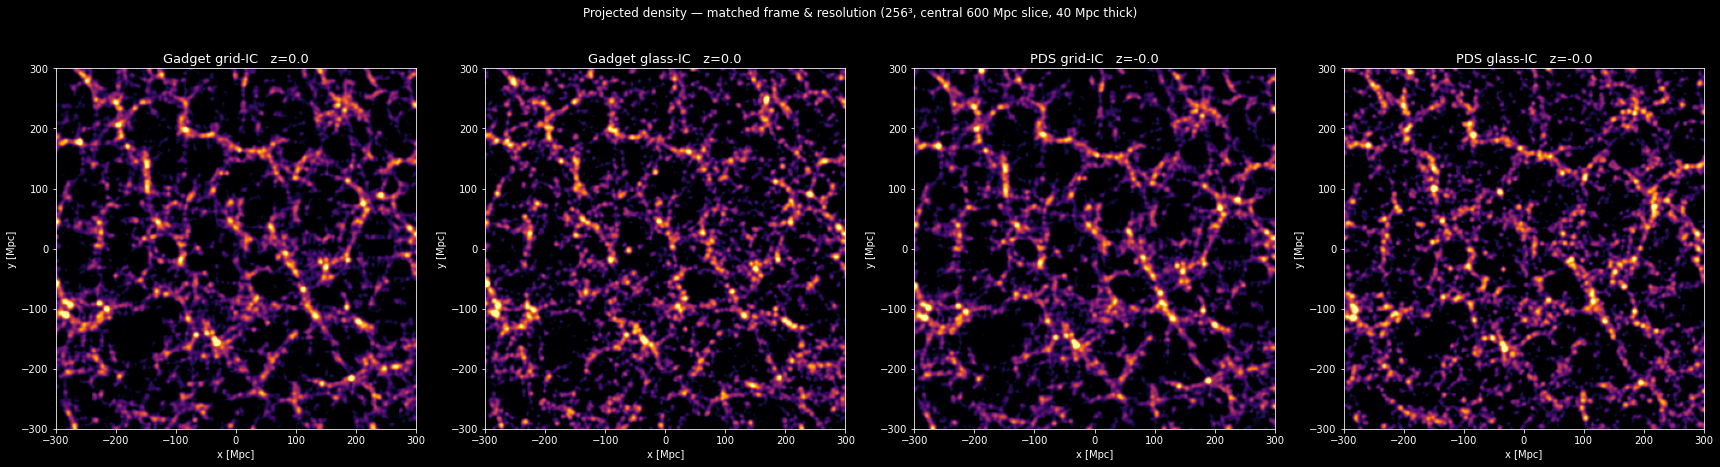

In [3]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, len(RUNS), figsize=(6*len(RUNS), 6.2))
for ax, (name, run) in zip(axes, RUNS.items()):
    # matched frame for ALL runs: PDS in stereographic coords, Gadget L/2-shifted onto the
    # same origin -> the three panels show the SAME structures (shared seed-137 realization),
    # now at matched 256^3 resolution so it is a particle-for-particle comparison.
    x, z = load_for_gadget_match(run, IDX_OF[0])
    d = np.log10(density_slice(x)+0.5)
    ax.imshow(d, origin='lower', extent=[-300,300,-300,300], cmap='inferno',
              vmin=np.percentile(d,40), vmax=np.percentile(d,99.7))
    ax.set_title('%s   z=%.1f' % (name, z), fontsize=13)
    ax.set_xlabel('x [Mpc]'); ax.set_ylabel('y [Mpc]')
fig.suptitle('Projected density — matched frame & resolution (256³, central 600 Mpc slice, 40 Mpc thick)', y=1.02)
plt.tight_layout(); plt.show()

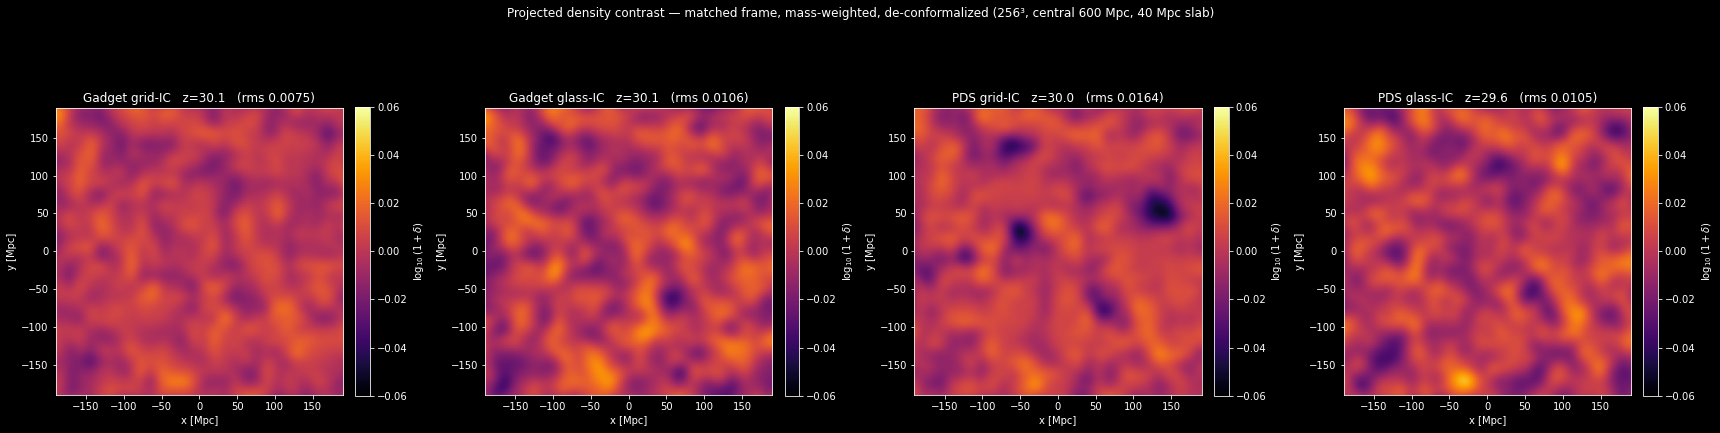

In [4]:
# --- density slice on a COMMON, physically meaningful scale -------------------
# density_slice() above returns a RAW PARTICLE COUNT: un-normalised and mass-blind. The
# three runs disagree on both, so no fixed vmin/vmax can ever line them up at z=30:
#     Gadget256 : m = 275.5 (uniform),            1.46 counts/pixel
#     PDS grid  : m = 308.5 (8028 values, 12%),   1.63 counts/pixel
#     PDS glass : m = 308.5 (uniform),            1.61 counts/pixel
# Raw log10(counts+0.5) then lands in three different places -- [0.267,0.315],
# [0.241,0.421], [0.285,0.359] -- so a single scale shows Gadget as nearly flat while
# PDS grid saturates. Two corrections are needed:
#
#  (1) weight by mass and divide by the map mean  ->  1 + delta   (kills the offset)
#  (2) de-conformalize the PDS masses:  m -> m / Omega^3,  Omega = 2R^2/(R^2+r^2).
#      The stereographic chart has physical volume element Omega^3 d^3x, so BOTH PDS
#      loads carry a smooth RADIAL gradient that is coordinate, not structure -- the grid
#      run through its masses (m ∝ Omega^3; that is exactly where the 12% spread comes
#      from, Omega^3 falling 10.7% from centre to domain edge), the glass run through its
#      stereographic number density. Across |x| < 300 Mpc that is a 2.8% decline:
#      negligible at z=0, but it DOMINATES this heavily smoothed z=30 map, where the real
#      signal is only ~0.5-1.7%. That is why the problem shows up on the ICs specifically.
#
# Sanity check on the data (not the estimator): in 3D, in the 280 Mpc cube with 15 Mpc
# cells and shot noise subtracted, the PDS grid IC matches Gadget to 1.0008. The fields
# agree; only the density estimator was wrong.
#
# NOTE the panels still will NOT look identical, and should not: the glass load is
# hyperuniform by construction (sub-Poissonian noise -- in 3D it even yields a negative
# variance after standard Poisson shot-noise subtraction), so its small-scale floor is
# genuinely unlike a grid load's. At 2 Mpc pixels with ~1.6 counts each, a z=30 map is
# mostly each load's discreteness noise, not structure. Increase `smooth` to compare
# structure rather than noise.

def load_match_with_mass(run, idx):
    """Matched frame (as load_for_gadget_match) but also returns de-conformalized masses."""
    L = 1200.0
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx))
    with h5py.File(f, 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
        m = h['PartType1/Masses'][:].astype(np.float64)
        z = float(h['Header'].attrs['Redshift'])
    if run['kind'] == 'gadget':
        x = x / HUB - L/2                    # Mpc/h -> Mpc, box frame -> matched frame
    else:
        r2 = (x**2).sum(1)                   # stereographic radius^2
        m = m / (2.0*R_CURV**2/(R_CURV**2 + r2))**3      # m -> m/Omega^3
    return x, m, z

def delta_slice(x, m, half=300.0, slab=20.0, ng=300, smooth=5.0):
    """Mass-weighted projected density normalised to its own mean -> 1 + delta."""
    x = x - np.median(x, 0)
    s = (np.abs(x[:,2]) < slab) & (np.abs(x[:,0]) < half) & (np.abs(x[:,1]) < half)
    H, _, _ = np.histogram2d(x[s,0], x[s,1], bins=ng, range=[[-half,half]]*2, weights=m[s])
    H = gaussian_filter(H.T, smooth)
    return H / H.mean()

plt.style.use('dark_background')
fig, axes = plt.subplots(1, len(RUNS), figsize=(6*len(RUNS), 6.2))
VLIM = 0.06                                  # ~ +-3 sigma of the z=30 field; same for all
for ax, (name, run) in zip(axes, RUNS.items()):
    x, m, z = load_match_with_mass(run, IDX_OF[30])
    d = np.log10(delta_slice(x, m))
    img = ax.imshow(d, origin='lower', extent=[-300,300,-300,300], cmap='inferno',
                    vmin=-VLIM, vmax=+VLIM)          # <-- identical scale, all 3 panels
    ax.set_title('%s   z=%.1f   (rms %.4f)' % (name, z, d.std()), fontsize=12)
    ax.set_xlabel('x [Mpc]'); ax.set_ylabel('y [Mpc]')
    ax.set_xlim(-190, 190); ax.set_ylim(-190, 190)
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04, label=r'$\log_{10}(1+\delta)$')
fig.suptitle('Projected density contrast — matched frame, mass-weighted, de-conformalized '
             '(256³, central 600 Mpc, 40 Mpc slab)', y=1.02)
plt.tight_layout(); plt.show()


## 2. Density evolution (PDS glass-IC)
The cosmic web assembling from z=5 to z=0 (physical geodesic-normal coordinates).

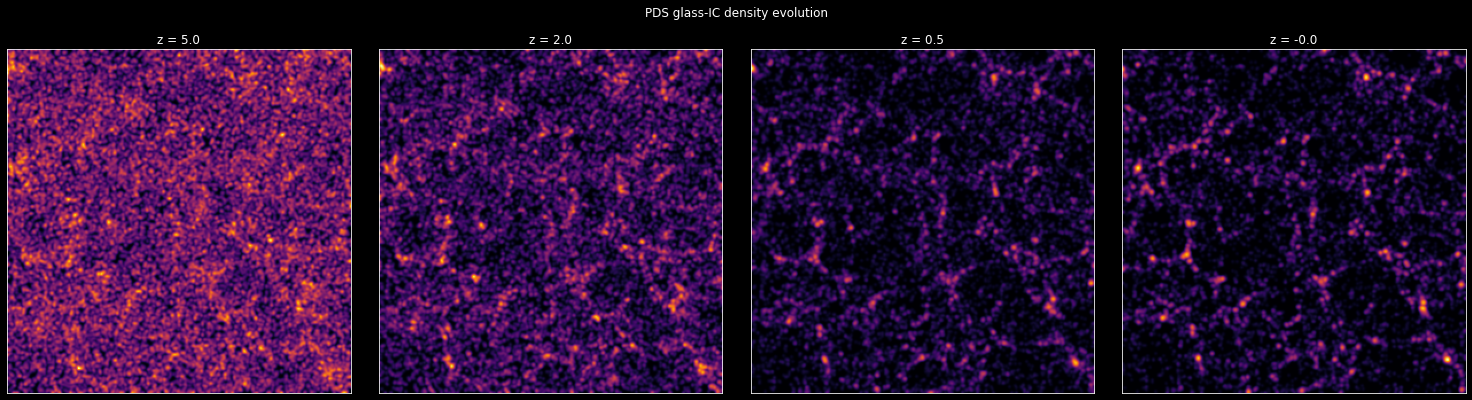

In [5]:
run = RUNS['PDS glass-IC']  # or 'PDS grid-IC'
zs = [5, 2, 0.5, 0]
fig, axes = plt.subplots(1, len(zs), figsize=(5.2*len(zs), 5.4))
for ax, zz in zip(axes, zs):
    x, z = load_phys(run, IDX_OF[zz]); d = density_slice(x)
    ax.imshow(np.log10(d+0.5), origin='lower', extent=[-300,300,-300,300], cmap='inferno')
    ax.set_title('z = %.1f' % z); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('PDS glass-IC density evolution', y=1.02)
plt.tight_layout(); plt.show()

## 3. Power-spectrum evolution
Raw P(k) (shot-noise subtracted only) at z = 10, 5, 2, 0, in a central cube that **fits
inside the dodecahedral domain** (`HALF=300` Mpc). Because the FFT window never touches the
domain boundary, both the PDS and Gadget runs sample only real volume and the P(k) is
**directly comparable with no pedestal subtraction**. The dashed line is a smooth analytic
linear reference (Eisenstein-Hu no-wiggle), anchored to Gadget's quasi-linear z=0 large
scales — the same theory curve in every panel. The z=0 curves should hug it on large scales
and rise above it on small scales (nonlinear growth).

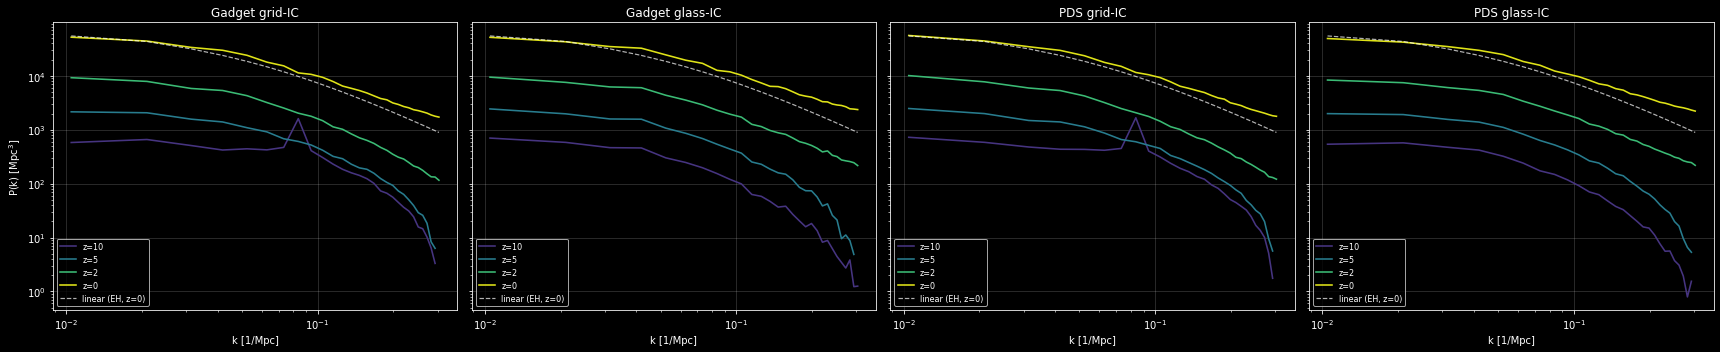

In [6]:
def Pk_lin_EH(k, Om0=OM, Ob0=0.0486, h=HUB, ns=0.9665, Tcmb=2.7255):
    # Eisenstein-Hu 1998 no-wiggle linear P(k) shape (arbitrary norm); k in 1/Mpc
    theta = Tcmb/2.7; omh2 = Om0*h*h; obh2 = Ob0*h*h
    s = 44.5*np.log(9.83/omh2)/np.sqrt(1+10*obh2**0.75)
    a = 1 - 0.328*np.log(431*omh2)*(Ob0/Om0) + 0.38*np.log(22.3*omh2)*(Ob0/Om0)**2
    Geff = Om0*h*(a + (1-a)/(1+(0.43*k*s)**4))
    q = (k/h)*theta**2/Geff
    C0 = 14.2 + 731.0/(1+62.5*q); L0 = np.log(2*np.e + 1.8*q)
    T = L0/(L0 + C0*q*q)
    return k**ns * T**2

z_show = [10, 5, 2, 0]
colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(z_show)))
fig, axes = plt.subplots(1, len(RUNS), figsize=(6*len(RUNS), 5), sharex=True, sharey=True)
pk_cache = {}

# smooth analytic linear reference (Eisenstein-Hu), anchored to Gadget's quasi-linear z=0
# large scales -- same theory curve in every panel (identical flat background for all runs).
gname    = next(n for n, r in RUNS.items() if r['kind'] == 'gadget')
kg0, Pg0 = clustering_pk(RUNS[gname], IDX_OF[0])
Plin     = Pk_lin_EH(kg0)
anc      = kg0 < 0.04
Plin    *= np.nanmean(Pg0[anc]) / np.nanmean(Plin[anc])

for ax, (name, run) in zip(axes, RUNS.items()):
    for z, c in zip(z_show, colors):
        k, P = clustering_pk(run, IDX_OF[z])   # raw P(k) in the fitting cube -- no subtraction
        pk_cache[(name, z)] = (k, P)
        ok = P > 0; ax.loglog(k[ok], P[ok], color=c, lw=1.6, label='z=%g' % z)
    ax.loglog(kg0, Plin, 'w--', lw=1.2, alpha=0.7, label='linear (EH, z=0)')
    ax.set_title(name); ax.set_xlabel('k [1/Mpc]'); ax.grid(alpha=0.2); ax.legend(fontsize=8)
axes[0].set_ylabel('P(k) [Mpc$^3$]')
plt.tight_layout(); plt.show()

## 4. P(k) ratios and growth
Left: PDS / Gadget P(k) ratio at z=0 (≈1 on well-sampled scales = the PDS reproduces Gadget).
Right: growth of the large-scale P(k) amplitude vs linear D(a)².

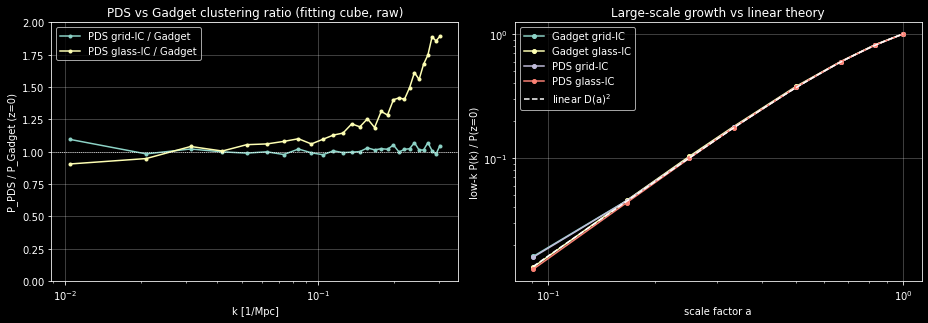

In [7]:
fig, (axr, axg) = plt.subplots(1, 2, figsize=(13, 4.6))
gname     = next(n for n, r in RUNS.items() if r['kind'] == 'gadget')
pds_names = [n for n, r in RUNS.items() if r['kind'] == 'pds']

# left: PDS/Gadget clustering ratio at z=0 (raw P(k), fitting cube -> no subtraction)
zz = 2 # 0, 5
kg, Pg = pk_cache[(gname, zz)]
for name in pds_names:
    kp, Pp = pk_cache[(name, zz)]
    n = min(len(Pg), len(Pp))
    r = Pp[:n]/np.where(Pg[:n] > 0, Pg[:n], np.nan)
    axr.semilogx(kg[:n], r, marker='o', ms=3, label=name + ' / Gadget')
axr.axhline(1, color='w', lw=0.8, ls=':'); axr.set_ylim(0, 2)
axr.set_xlabel('k [1/Mpc]'); axr.set_ylabel('P_PDS / P_Gadget (z=0)')
axr.legend(); axr.grid(alpha=0.3); axr.set_title('PDS vs Gadget clustering ratio (fitting cube, raw)')

# right: large-scale growth vs linear D(a)^2
zs = [10, 5, 3, 2, 1, 0.5, 0.2, 0]
for name, run in RUNS.items():
    amp = []
    for z in zs:
        if (name, z) in pk_cache: k, P = pk_cache[(name, z)]
        else: k, P = clustering_pk(run, IDX_OF[z])
        nlow = max(1, len(P)//4); amp.append(np.nanmean(np.where(P[:nlow] > 0, P[:nlow], np.nan)))
    amp = np.array(amp); a = np.array([1/(1+z) for z in zs])
    axg.loglog(a, amp/amp[-1], marker='o', ms=4, label=name)
aa = np.linspace(1/11.0, 1, 50)
axg.loglog(aa, (np.array([Dgrow(x) for x in aa])/Dgrow(1.0))**2, 'w--', label='linear D(a)$^2$')
axg.set_xlabel('scale factor a'); axg.set_ylabel('low-k P(k) / P(z=0)')
axg.legend(); axg.grid(alpha=0.3); axg.set_title('Large-scale growth vs linear theory')
plt.tight_layout(); plt.show()

## 5. Grid load vs glass load — the high-k lattice imprint

§3 (with the fitting cube) shows the two loads give the *same* large-scale P(k). Where they
differ is at **high k**: a rectangular grid load imprints sharp **Bragg peaks** at the
lattice frequency, while the glass is sub-Poisson with none. The grid peaks dominate the
early-time small-scale field and only wash out once nonlinear evolution takes over. We track
the peak high-k power (P/shot, k≈0.3–0.6 /Mpc; the grid lattice is near the Nyquist of the
256³ load) versus redshift. (This uses `half=350` to gather more high-k modes; it stays
inside the domain and the boundary is irrelevant to a high-k peak diagnostic anyway.)

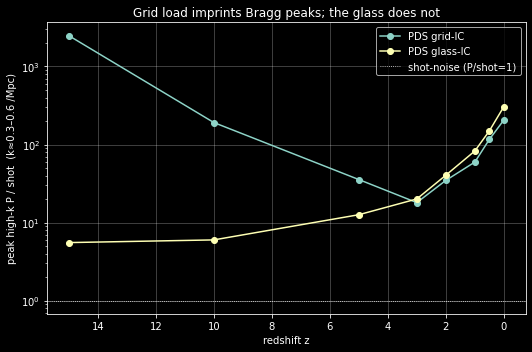

peak high-k P/shot:


  PDS grid-IC      z=15:  2483.6   z=10:  191.3   z=0:  206.0


  PDS glass-IC     z=15:     5.5   z=10:    6.0   z=0:  305.8


In [8]:
def hik_bragg(x, half=350.0, ng=128, klo=0.30, khi=0.60):
    # peak high-k power / shot in a band near the 256^3 load lattice frequency
    x = x - np.median(x, 0)
    m = (np.abs(x) < half).all(1); xx = x[m] + half; L = 2*half; N = len(xx)
    idx = np.clip((xx/L*ng).astype(int), 0, ng-1)
    g = np.zeros((ng,)*3); np.add.at(g, (idx[:,0], idx[:,1], idx[:,2]), 1.0)
    d = g/g.mean() - 1.0; P = np.abs(np.fft.fftn(d))**2 * L**3/ng**6
    kf = 2*np.pi/L
    kk = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(ng,1/ng)**2]*3, indexing='ij')))*kf
    shot = L**3/N; band = (kk >= klo) & (kk < khi)
    return P[band].max()/shot

pds_names = [n for n, r in RUNS.items() if r['kind'] == 'pds']
z_track   = [15, 10, 5, 3, 2, 1, 0.5, 0]
fig, ax = plt.subplots(figsize=(7.5, 5))
for name in pds_names:
    run = RUNS[name]
    br = [hik_bragg(load_for_gadget_match(run, IDX_OF[z])[0]) for z in z_track]
    ax.semilogy(z_track, br, marker='o', label=name)
ax.axhline(1.0, color='w', ls=':', lw=0.8, label='shot-noise (P/shot=1)')
ax.invert_xaxis()
ax.set_xlabel('redshift z'); ax.set_ylabel('peak high-k P / shot  (k≈0.3–0.6 /Mpc)')
ax.set_title('Grid load imprints Bragg peaks; the glass does not')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('peak high-k P/shot:')
for name in pds_names:
    run = RUNS[name]
    vals = {z: hik_bragg(load_for_gadget_match(run, IDX_OF[z])[0]) for z in (15, 10, 0)}
    print(f"  {name:<16} z=15:{vals[15]:8.1f}   z=10:{vals[10]:7.1f}   z=0:{vals[0]:7.1f}")

## 6. Apples to apples: separating the LOAD effect from the TOPOLOGY effect

Everything above compared PDS runs against a single flat reference that used a **grid**
load, so "PDS glass vs Gadget" mixed two different things: the change of topology *and*
the change of particle load. With `gadget256_glass` (identical to `gadget256_flat` in box,
seed, softening, output times, binary and `Config.sh` — only the load differs) the 2x2 is
complete and the two effects factorise:

| ratio | isolates |
|---|---|
| Gadget glass / Gadget grid | **load effect alone** (flat topology throughout) |
| PDS grid / Gadget grid | **topology effect alone** (grid load throughout) |
| PDS glass / Gadget glass | topology effect, measured on the glass load |
| PDS glass / Gadget grid | the mixed ratio plotted in section 4 |

If the high-k excess we attributed to "the glass" is really a load property, it should
appear in **Gadget glass / Gadget grid** too — where no topology is involved at all.

/tmp/ipykernel_1967460/336645006.py:13: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(kn[:n][ok], (Pn[:n]/Pd[:n])[ok], color=c, lw=1.6, marker='o', ms=2.5,


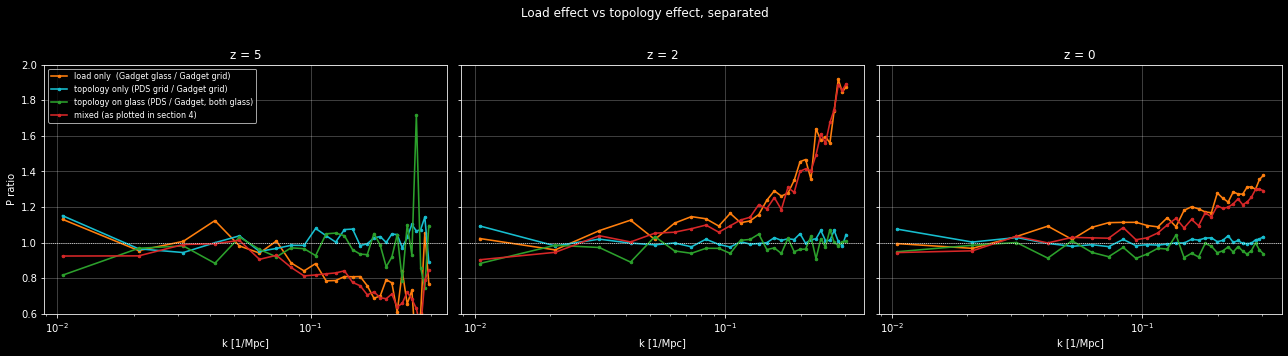

mean ratio for k > 0.18 :
   z             load only            topology only       topology on glass                   mixed 


   5                   0.719                   1.037                   1.005                   0.689


   2                   1.615                   1.025                   0.991                   1.602


   0                   1.285                   1.013                   0.960                   1.233


In [9]:
zs_cmp = [5, 2, 0]
fig, axes = plt.subplots(1, len(zs_cmp), figsize=(6*len(zs_cmp), 4.8), sharey=True)
pairs = [('Gadget glass-IC', 'Gadget grid-IC',  'load only  (Gadget glass / Gadget grid)', 'tab:orange'),
         ('PDS grid-IC',     'Gadget grid-IC',  'topology only (PDS grid / Gadget grid)',  'tab:cyan'),
         ('PDS glass-IC',    'Gadget glass-IC', 'topology on glass (PDS / Gadget, both glass)', 'tab:green'),
         ('PDS glass-IC',    'Gadget grid-IC',  'mixed (as plotted in section 4)',         'tab:red')]
for ax, z in zip(axes, zs_cmp):
    for num, den, lab, c in pairs:
        kn, Pn = clustering_pk(RUNS[num], IDX_OF[z])
        kd, Pd = clustering_pk(RUNS[den], IDX_OF[z])
        n = min(len(Pn), len(Pd))
        ok = Pd[:n] > 0
        ax.semilogx(kn[:n][ok], (Pn[:n]/Pd[:n])[ok], color=c, lw=1.6, marker='o', ms=2.5,
                    label=lab if z == zs_cmp[0] else None)
    ax.axhline(1, color='w', lw=0.8, ls=':')
    ax.set_xlabel('k [1/Mpc]'); ax.set_title(f'z = {z}')
    ax.grid(alpha=0.3); ax.set_ylim(0.6, 2.0)
axes[0].set_ylabel('P ratio')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Load effect vs topology effect, separated', y=1.02)
plt.tight_layout(); plt.show()

# quantify the high-k end
print('mean ratio for k > 0.18 :')
print(f'{"z":>4}' + ''.join(f'{lab.split("(")[0][:22]:>24}' for _,_,lab,_ in pairs))
for z in zs_cmp:
    row = f'{z:4g}'
    for num, den, lab, c in pairs:
        kn, Pn = clustering_pk(RUNS[num], IDX_OF[z]); kd, Pd = clustering_pk(RUNS[den], IDX_OF[z])
        n = min(len(Pn), len(Pd)); sel = (kn[:n] > 0.18) & (Pd[:n] > 0)
        row += f'{np.mean(Pn[:n][sel]/Pd[:n][sel]):24.3f}'
    print(row)

### Caveats / interpretation
- **Why the analysis cube must fit inside the domain (the old "pedestal").** A PDS run only
  has particles inside the dodecahedral fundamental domain (inradius ≈491 Mpc at the faces).
  A `HALF=400` FFT cube has corners at 400·√3 ≈ 693 Mpc, so **~7% of its volume (the corners)
  is hard vacuum** — a fixed, sharp-edged empty shape. FFT-ing a bounded shape measures the
  true clustering *convolved with that shape's own power spectrum* (the standard survey
  window/mask effect), which dumps enormous power at low k: a *uniform, unclustered* point set
  in the same shape gives a low-k P(k) of ~2.7×10⁶, matching the measured "pedestal" to a few
  percent — i.e. the pedestal was **100% geometry, 0% physics**. It is fixed in comoving
  coordinates (does not grow), which is why subtracting the first snapshot removed it and why
  it was identical for the grid and glass loads. **Using `HALF=300` (corner 520 Mpc, fully
  inside) removes it at the source**: the pure-mask low-k power drops from 2.7×10⁶ to ~2, the
  raw PDS/Gadget low-k ratio is ~0.85–0.9× with no subtraction, and the earlier k≈0.03 "dip"
  (an over-subtraction artifact) is gone. Gadget is unaffected either way — its periodic box
  is fully sampled everywhere — which is exactly why the naive "same volume ⇒ same spectrum"
  expectation only failed for the PDS.
- **What the glass fixes is the high-k Bragg imprint (§5).** The rectangular grid load has
  sharp lattice peaks (~2500× shot at z=15, ~30000× in the raw IC); the glass is sub-Poisson
  with none (~5× shot). These wash out under nonlinear growth by z≈2.
  > **Superseded in part (§6, 2026-09).** This bullet used to end "…so the two runs agree at
  > z=0 — the glass mainly cleans up the *early-time* small-scale field". That is wrong: the
  > glass carries low but **broadband** small-scale noise (a lattice concentrates its
  > discreteness into sharp peaks and leaves little in between), and that extra seed power is
  > amplified by non-linear collapse. Measured against the *grid* load at k > 0.18: **0.72 at
  > z=5, 1.62 at z=2, 1.29 at z=0** — the glass does not "agree at z=0", it ends ~30% high.
  > §6 shows this ratio is reproduced within a few percent by **Gadget glass / Gadget grid**,
  > i.e. it is a pure particle-load effect with no topology involved.
- **Frame.** PDS P(k) is in **stereographic** coordinates (origin-centred), Gadget shifted by
  L/2 onto the same origin. The geodesic-normal map (Ω≈2 stretch) is used only for the
  *physical* density slices (§1–2).
- The **discrete topology modes** (n=12,20 → k≈0.004–0.007 /Mpc) are *below* the fitting
  cube's fundamental (k_f = 2π/600 ≈ 0.010 /Mpc), so they do not enter these panels at all;
  the cleanest discrete signal is the ID-matched displacement field (median ~2 Mpc at z=0). To
  probe them one needs the full-domain intrinsic spectrum, not a Cartesian sub-cube.